In [1]:
from pathlib import Path
from typing import Tuple

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

# np.set_printoptions(precision=4)

# 1
n class and in the text we have developed the Harris operator. To find the Harris points you need to compute the gradients in both the X and Y directions. These will probably have to be lightly filtered using a Gaussian to be well behaved. You can do this either the “naive” way - filter the image and then do simple difference between left and right (X gradient) or up and down (Y gradient) - or you can take an analytic derivative of a Gaussian in X or Y and use that filter. The scale of the filtering is up to you. You may play with the size of the Gaussian as it will interact with the window size of the corner detection.


## Part A

Write functions to compute both the X and Y gradients. Try your code on both transA and simA. 

To display the output, adjoin the two gradient images(X and Y) to make a new, twice as wide, single image (the "gradient-pair"). Since gradients have negative and positive values, you’ll need to produce an image that is gray for 0.0 and black is negative and white is positive.

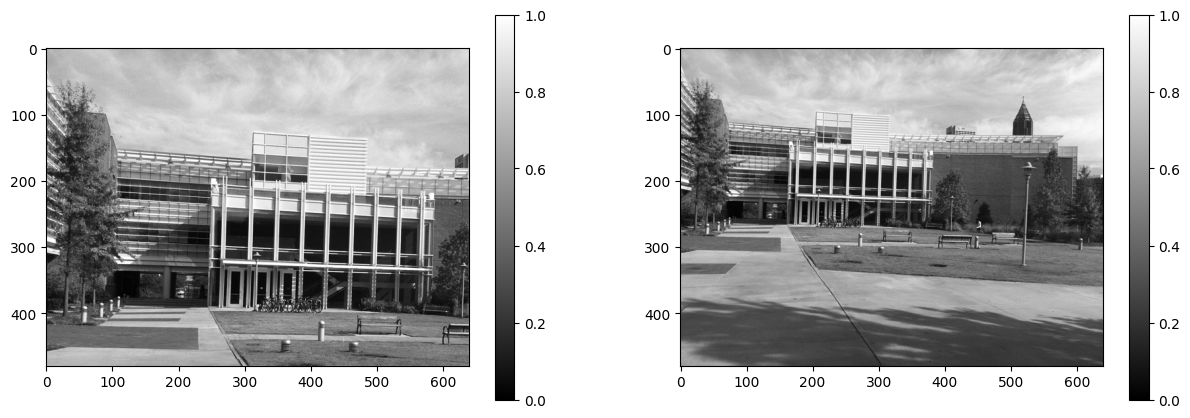

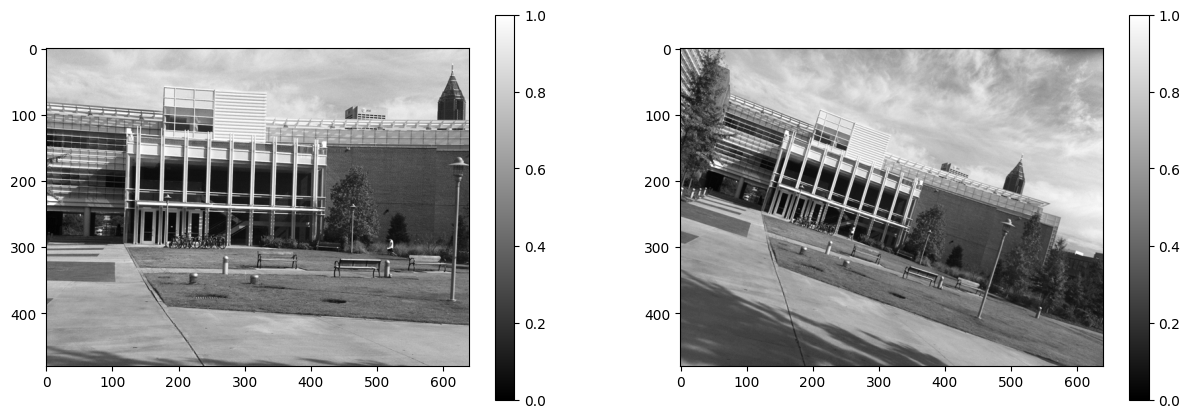

In [2]:
input_dir = Path('input')

img_trans_a = cv.imread(str(input_dir / 'transA.jpg'), cv.IMREAD_UNCHANGED)
img_sim_a = cv.imread(str(input_dir / 'simA.jpg'), cv.IMREAD_UNCHANGED)

img_trans_b = cv.imread(str(input_dir / 'transB.jpg'), cv.IMREAD_UNCHANGED)
img_sim_b = cv.imread(str(input_dir / 'simB.jpg'), cv.IMREAD_UNCHANGED)

img_trans_a = img_trans_a.astype(np.float32) / 255
img_sim_a = img_sim_a.astype(np.float32) / 255

img_trans_b = img_trans_b.astype(np.float32) / 255
img_sim_b = img_sim_b.astype(np.float32) / 255

plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.imshow(img_trans_a, cmap="gray")
plt.colorbar()
plt.subplot(122)
plt.imshow(img_sim_a, cmap="gray")
plt.colorbar()
plt.show()


plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.imshow(img_trans_b, cmap="gray")
plt.colorbar()
plt.subplot(122)
plt.imshow(img_sim_b, cmap="gray")
plt.colorbar()
plt.show()

In [3]:
def compute_gradients(img, kernel_size=3, sigma=3):
    # img = img.copy().astype(np.float32)
    img = cv.GaussianBlur(img, (kernel_size, kernel_size), sigma)
    sobelx = cv.Sobel(img,cv.CV_64F,1,0,ksize=kernel_size)
    sobely = cv.Sobel(img,cv.CV_64F,0,1,ksize=kernel_size)

    # sobelx = np.uint8(np.absolute(sobelx))    
    # sobely = np.uint8(np.absolute(sobely))    
    return sobelx, sobely

def concat_images(img1, img2):
    return np.hstack([img1, img2])

### Display the "gradient pair" (a concatenation of both images)

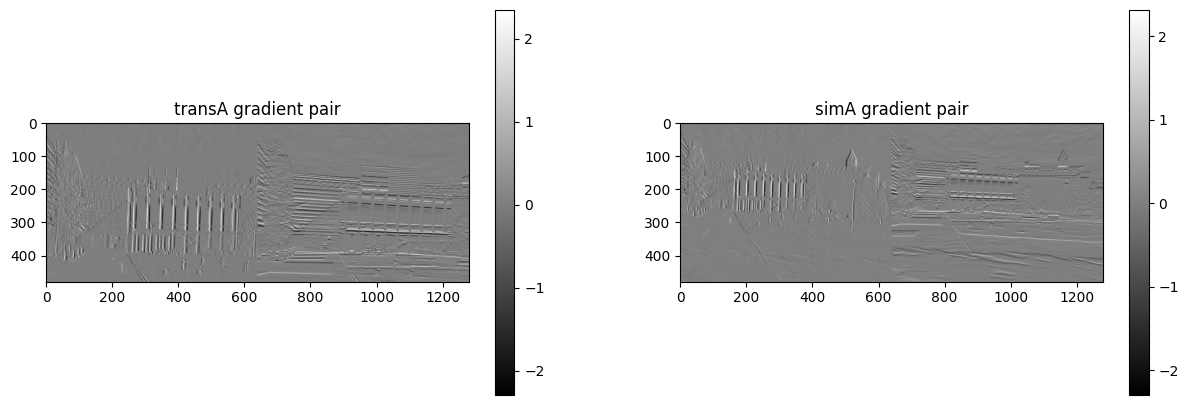

In [4]:


trans_a_sobelx, trans_a_sobely = compute_gradients(img_trans_a, 3, 3)
trans_a_gradient_pair = concat_images(trans_a_sobelx, trans_a_sobely)

sim_a_sobelx, sim_a_sobely = compute_gradients(img_sim_a, 3, 3)
sim_a_gradient_pair = concat_images(sim_a_sobelx, sim_a_sobely)
plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.title("transA gradient pair")
# plt.imshow(trans_a_gradient_pair, cmap='gray', vmin=-1, vmax=1)
plt.imshow(trans_a_gradient_pair, cmap='gray')
plt.colorbar()
plt.subplot(122)
plt.title("simA gradient pair")
plt.imshow(sim_a_gradient_pair, cmap='gray')
plt.colorbar()
plt.show()

## Part B
Now you can compute the Harris value for the image. As a reminder the Harris value was defined as:

$R = \det(M) - \alpha \, \text{trace}(M)^2$

where

$ M = \sum_{x, y} w(x, y) \begin{bmatrix} I_x^2 & I_x I_y \\ I_x I_y & I_y^2 \end{bmatrix}$

The only design decisions are the size of the window (the sum), the windowing function that controls the weights, and the value of α in the Harris scoring function. Remember you can check you code on the checkerboard images, though those might use a different optimal window size than the real ones.

Write code to compute the Harris value. You can try the weights just equal to 1. But it might work better with a smoother Gaussian that is higher at the middle and falls off gradually. Your output is a scalar function. Apply to transA, transB, simA, and simB.
(To display the output reasonably you will have to scale the image values to be in a range of 0-255 or 0.0 to 1.0, depending upon how you deal with images.)



In [5]:
def find_harris_value(img, alpha=0.05, window_size=(7,7), sigma=5):
    I_x, I_y = compute_gradients(img)
    I_x_I_y = I_x * I_y

    I_x_2 = np.square(I_x)
    I_y_2 = np.square(I_y)
    
    I_x_2 = cv.GaussianBlur(I_x_2, window_size, sigma)
    I_y_2 = cv.GaussianBlur(I_y_2, window_size, sigma)

    I_x_I_y = cv.GaussianBlur(I_x_I_y, window_size, sigma)

    M_det = I_x_2 * I_y_2 - np.square(I_x_I_y)
    M_trace = I_x_2 + I_y_2
    R = M_det - alpha * np.square(M_trace)
    return R


In [6]:
H = find_harris_value(img_trans_a)
print("Max value", H.max())
print("min value", H.min())

Max value 0.5615218909363499
min value -0.299543789766468


## Part C

Finally you can find some corner points. To do this requires two steps: thresholding and non- maximal suppression. You’ll need to choose a threshold value that eliminates points that don’t seem to be plausible corners. And for the non-maximal suppression, you’ll need to choose a radius (could be size of a side of a square window instead of a circle radius) over which a pixel has to be a maximum.

Write a function to threshold and do non-maximal suppression on the Harris output. Surprise, huh? Adjust the threshold and radius until you get a “nice” set of points, probably on the order of a hundred or two (or three?). But use your judgment in terms of getting enough points. Are there any points that are visible in both images but not found as corners in both?


In [7]:
# Apply non maximum supression and thresholding
# Points are returns as i,j - i for row and j for column
def find_corner_points(H, threshold=0.01):
    max_filter = ndimage.maximum_filter(H, size=7)
    min_filter = ndimage.minimum_filter(H, size=7)

    mask = (max_filter == H) & (max_filter != min_filter) & (H >= threshold)
    indices = np.argwhere(mask)
    values = [H[index[0],index[1]] for index in indices]
    sorted_indices = np.argsort(values)[::-1]
    peaks = indices[sorted_indices]
    
    return peaks

def view_corners(corners, img, radius=1):
    corners_img = np.copy(img)
    corners_img = cv.cvtColor(corners_img, cv.COLOR_GRAY2BGR)

    for pt in corners:
        cv.circle(corners_img, pt[::-1], radius=radius, color=[200,200,0], thickness=2)

    
    plt.figure(figsize=(20,7))
    plt.imshow(corners_img, cmap="gray",)
    plt.colorbar()

    plt.show()

def show_harris_corners(img, alpha=0.05, window_size=7, sigma=5, threshold=0.01):
    H = find_harris_value(img, alpha=alpha, window_size=(window_size, window_size), sigma=sigma)
    corner_points = find_corner_points(H, threshold)
    view_corners(corner_points, img)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..200.0].


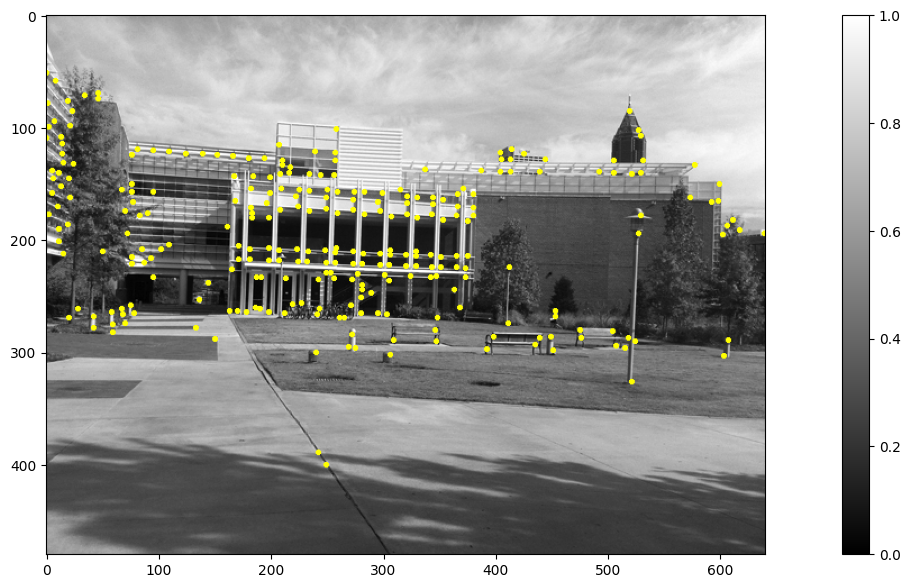

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..200.0].


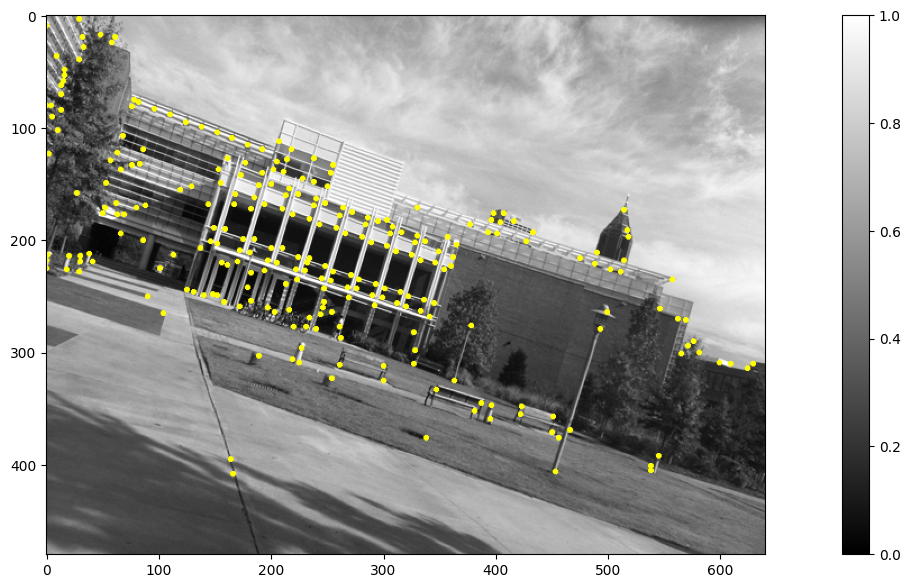

In [8]:
show_harris_corners(img_sim_a, threshold=0.01)
show_harris_corners(img_sim_b)



# 2 Sift Features


Now that you have keypoints for both image pairs, we can compute descriptors. You will be glad to know that we do not expect you to write your own SIFT descriptor code. Instead you’ll use a MATLAB package called VLFeat and for Python, the SIFT or SURF classes in OpenCV. In our past experience using VLFeat with Python is not a good idea. So please use OpenCV with Python. Please check out the supplemental document for instructions on using SIFT in VLFeat/MATLAB or OpenCV/Python.

The standard use of a SIFT library consists of you just providing an image and the library does its thing: finds interest points at various scales and computes descriptors at each point. We’re going to use the library code only to compute the orientation histogram descriptors for the interest points you have already detected from Problem 1. To do so, you need to provide a scale setting and an orientation for each feature point as well as the gradient magnitude and angle for each pixel. The scale we’ll fix to 1.0 (see accompanying SIFT software usage tutorial). The orientation needs to be computed from the gradients:

$ angle = atan2(I_x, I_y) $

But, you already have the gradient images! So you can create an “angle” image and then for a given feature point at $<u_i, u_v>$ you can get the gradient direction.





### Part A

Write the function to compute the angle. Then for the set of interest points you found above, plot the points for all of transA, transB, simA and simB on the respective images and draw a little line that shows the direction of the gradient. In MATLAB if you want you can use the VLFeat function vl_plotframe to draw the feature points locations and the angle. You’ll need to figure it out - look at http://www.vlfeat.org/overview/sift.html and also the documentation for vl_plotframe. In OpenCV you can use the method drawKeypoints().

In [9]:
img_trans_a_uint8 = cv.imread(str(input_dir / 'transA.jpg'), cv.IMREAD_UNCHANGED)
img_trans_b_uint8 = cv.imread(str(input_dir / 'transB.jpg'), cv.IMREAD_UNCHANGED)
img_sim_a_uint8 = cv.imread(str(input_dir / 'simA.jpg'), cv.IMREAD_UNCHANGED)
img_sim_b_uint8 = cv.imread(str(input_dir / 'simB.jpg'), cv.IMREAD_UNCHANGED)

In [10]:
def get_angle(img):
    I_x, I_y = compute_gradients(img)
    angle_img = np.arctan2(I_y, I_x)
    angle_img = np.rad2deg(angle_img)
    return angle_img

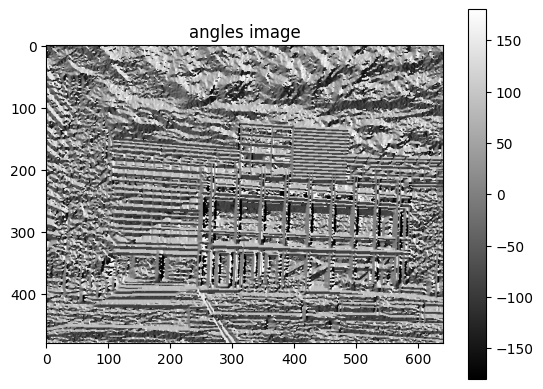

In [11]:
img_angle = get_angle(img_trans_a_uint8)
plt.title("angles image")
plt.imshow(img_angle, cmap="gray")
plt.colorbar()
plt.show()

In [12]:

# angles should be -180 to 180 degrees.
# key points are [i,j] - [row, col]
def img_with_angles(angle_img, img, key_points, thickness=2, num_points=50, color=[255,0,0], arrow_length=30):
    img = cv.cvtColor(img.copy(), cv.COLOR_GRAY2RGB)
    key_points = key_points[:num_points]
    angles = np.deg2rad([angle_img[pt[0],pt[1]] for pt in key_points])
    for angle, kp in zip(angles, key_points):
        pt1 = kp[::-1]
        x = pt1[0] + arrow_length * np.cos(angle)
        y = pt1[1] + arrow_length * np.sin(angle)
        pt2 = [x,y]
        pt2 = np.round(pt2).astype(int) # Need to round it because we arrive somwhere close to a pixel
        # I can also find the nearest pixel but round is easier and good enough for long enough arrows
        
        img = cv.arrowedLine(img, pt1, pt2, color, thickness)

    for kp in key_points:
        img = cv.circle(img, kp[::-1], 3, [0,0,255], 2)
    # print(key_points)
    # print(angles)
    return img


In [13]:
def show_gradient_directions(img):
    kp = find_corner_points(find_harris_value(img))
    # sift = cv.SIFT_create()
    # kp, des = sift.detectAndCompute(img_trans_a_uint8, None)
    # kp = cv.KeyPoint_convert(kp)
    # kp = np.round(kp).astype(int)
    img_angle = get_angle(img)
    new_img = img_with_angles(img_angle, img, kp)
    plt.imshow(new_img)
    plt.show()

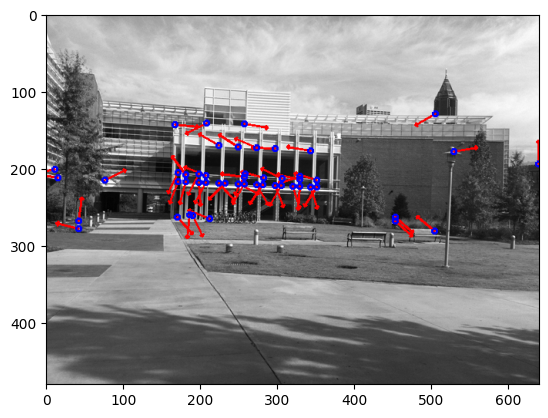

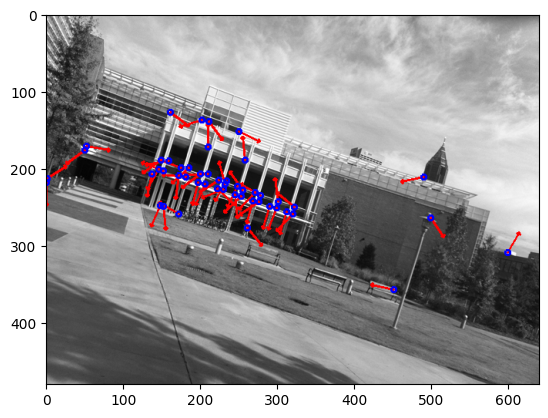

In [14]:
show_gradient_directions(img_sim_a_uint8)
show_gradient_directions(img_sim_b_uint8)

### Part B

Now we’re going to call the SIFT descriptor code. You need to pass in each keypoint location along with its scale and orientation. This process is covered in more detail in the accompanying supplemental document.

Once we have the descriptors, we need to match them. This is what we called putative matches in class. Given keypoints in two images, get the best matches. Both VLFeat and OpenCV have functions for computing matches (e.g. for VLFeat it’s called vl_ubcmatch.) You will call those and then you will make an image that has both the A and B version adjoined and that draws lines from each keypoint in the left to the matched keypoint in the right. We’ll call this new image the putative-pair-image.

Now, both of the SIFT packages have functions to draw matches. ***But you are not permitted to use them!!!*** This way you will have to identify the location of each keypoint and its match, and explicitly draw the line. This tells us you have a good handle on the data structures that you are using.

Write the function to call the appropriate SIFT descriptor extraction function with the necessary input data structures. Do this for all the keypoints in both pairs of images. Then call the matching functions of VLFeat or OpenCV to compute the best matches between the left and right images of each pair. Then create the putative-pair-image for both transA–transB and simA–simB pair. You must write your own drawing function (note you may use OpenCV’s line() function or MATLAB’s plot() function).


In [15]:
def get_key_points(img):
    img = img.copy()
    img = img.astype(np.float32) / 255
    pts = find_corner_points(find_harris_value(img))
    angle = get_angle(img).astype(float)
    Ix, Iy = compute_gradients(img)
    grad_size = np.sqrt(np.square(Ix) + np.square(Iy)).astype(float)

    kps = np.array([cv.KeyPoint(pt[1].astype(float), pt[0].astype(float), 15, angle[pt[0],pt[1]], grad_size[pt[0],pt[1]], 0) for pt in pts])
    return kps

def draw_my_key_points(img, kps):
    img = cv.cvtColor(img.copy(), cv.COLOR_GRAY2RGB)
    cv.drawKeypoints(img, kps, img, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    plt.figure(figsize=(15,10))
    plt.imshow(img)

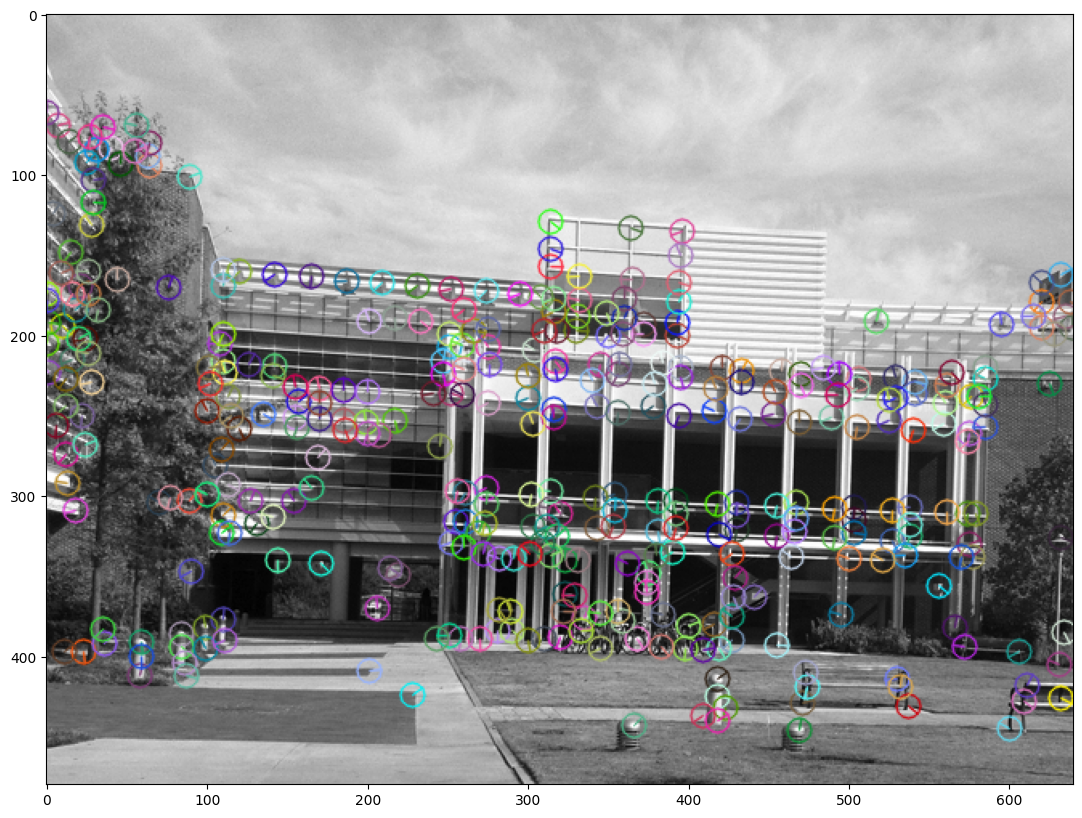

In [33]:
img1 = img_trans_a_uint8

kps = get_key_points(img1)
draw_my_key_points(img1, kps)

In [34]:
img1 = img_trans_a_uint8
img2 = img_trans_b_uint8

kp1 = get_key_points(img1)
kp2 = get_key_points(img2)

def get_matches(img1, img2, kp1, kp2):

    sift = cv.SIFT_create()
    _, des1 = sift.compute(img1, kp1)
    _, des2 = sift.compute(img2, kp2)

    bfm = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)
    matches = bfm.match(des1.astype(np.uint8),des2.astype(np.uint8))
    matches = sorted(matches, key = lambda x: x.distance)
    return matches

In [46]:
m = matches[100]
print([m.trainIdx, m.distance, m.queryIdx, m.imgIdx])

[188, 340.0, 211, 0]


(480, 1280, 3)


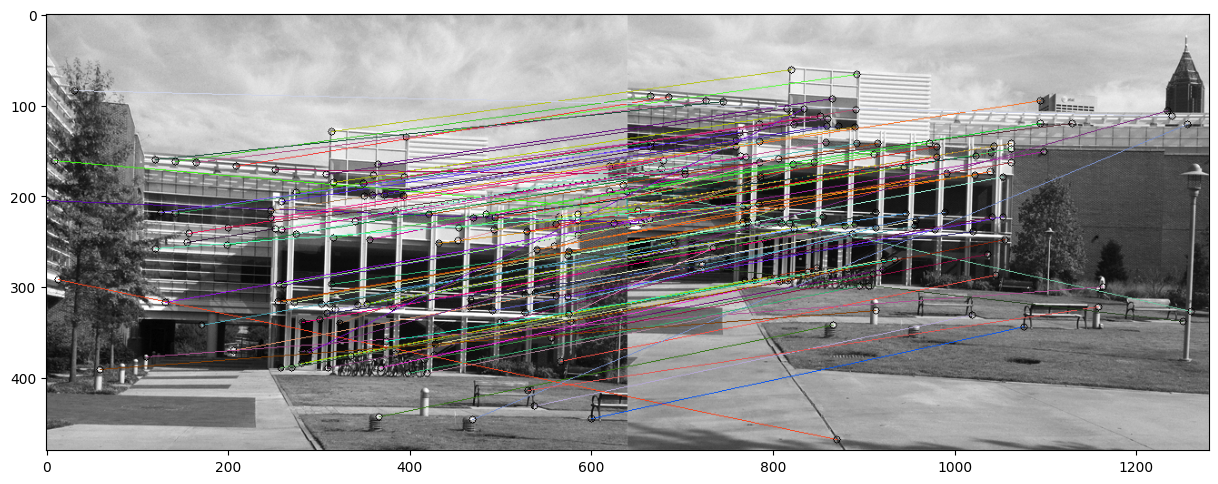

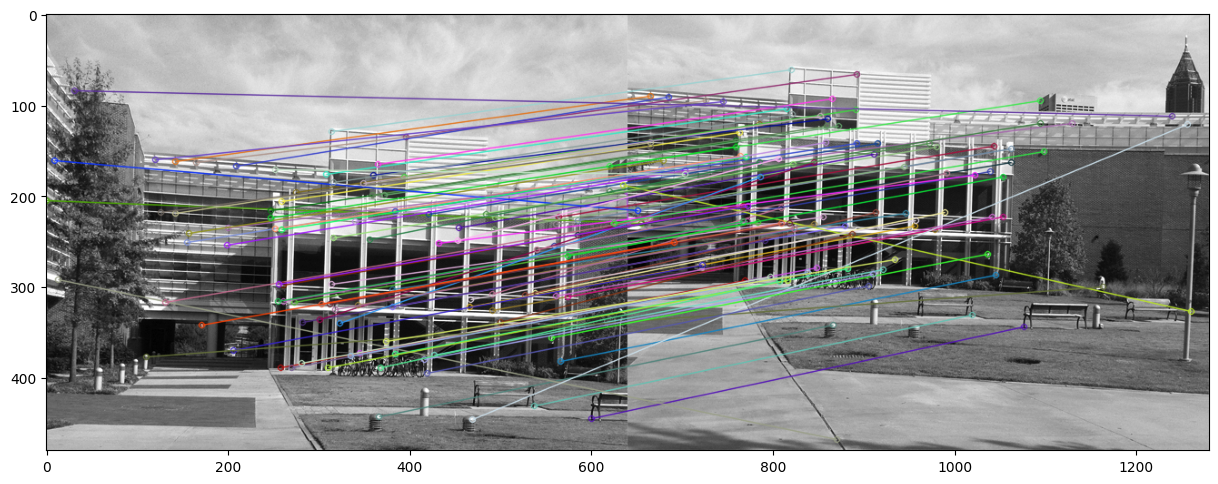

(<matplotlib.image.AxesImage at 0x1e399aae650>, None)

In [86]:
def generate_color(): 
  # Generate random values for red, green, and blue 
  r = np.random.randint(0, 255) 
  g = np.random.randint(0, 255) 
  b = np.random.randint(0, 255) 
  
  color = [r,g,b]
  return color 

def draw_matches(img1, img2, kp1, kp2, matches):
    img1 = cv.cvtColor(img1.copy(), cv.COLOR_GRAY2RGB)
    img2 = cv.cvtColor(img2.copy(), cv.COLOR_GRAY2RGB)
    new_img = concat_images(img1, img2)
    print(new_img.shape)

    for match in matches:
        kp1_index = match.queryIdx 
        kp2_index = match.trainIdx
        pt1 = np.int32(kp1[kp1_index].pt)
        pt2 = np.int32(kp2[kp2_index].pt)
        pt2 = [pt2[0] + img1.shape[1], pt2[1]]
        new_img = cv.line(new_img, pt2, pt1, generate_color(), 1)
        new_img = cv.circle(new_img, pt1, 4, 2)
        new_img = cv.circle(new_img, pt2, 4, 2)

        
    plt.figure(figsize=(15,10))
    plt.imshow(new_img)
    plt.show()

matches = get_matches(img1, img2, kp1, kp2)

draw_matches(img1, img2, kp1, kp2, matches)

img3 = cv.drawMatches(img1, kp1, img2, kp2, matches[:100], None, flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
 
plt.figure(figsize=(15,10))
plt.imshow(img3),plt.show()


[((2.3980672359466553, 243.50765991210938), 2.530487060546875, 302.44091796875, 0.030460316687822342), ((2.6690869331359863, 455.9715576171875), 2.0575339794158936, 83.61483764648438, 0.04026436060667038), ((2.7552497386932373, 141.99371337890625), 2.4420268535614014, 301.58392333984375, 0.031564485281705856), ((2.9275214672088623, 126.46519470214844), 2.6234476566314697, 307.50433349609375, 0.029068222269415855), ((3.5190837383270264, 322.7339782714844), 2.5410144329071045, 61.670074462890625, 0.02107417769730091), ((3.5427091121673584, 109.43488311767578), 3.224370241165161, 311.66290283203125, 0.03364899381995201), ((3.5544326305389404, 185.43289184570312), 1.9047517776489258, 252.87356567382812, 0.022199520841240883), ((3.7526676654815674, 356.9484558105469), 3.1076526641845703, 218.4879913330078, 0.014667538926005363), ((3.7966368198394775, 293.44140625), 2.4713733196258545, 283.5173645019531, 0.03623019531369209), ((3.8577663898468018, 209.89797973632812), 2.6260361671447754, 31.

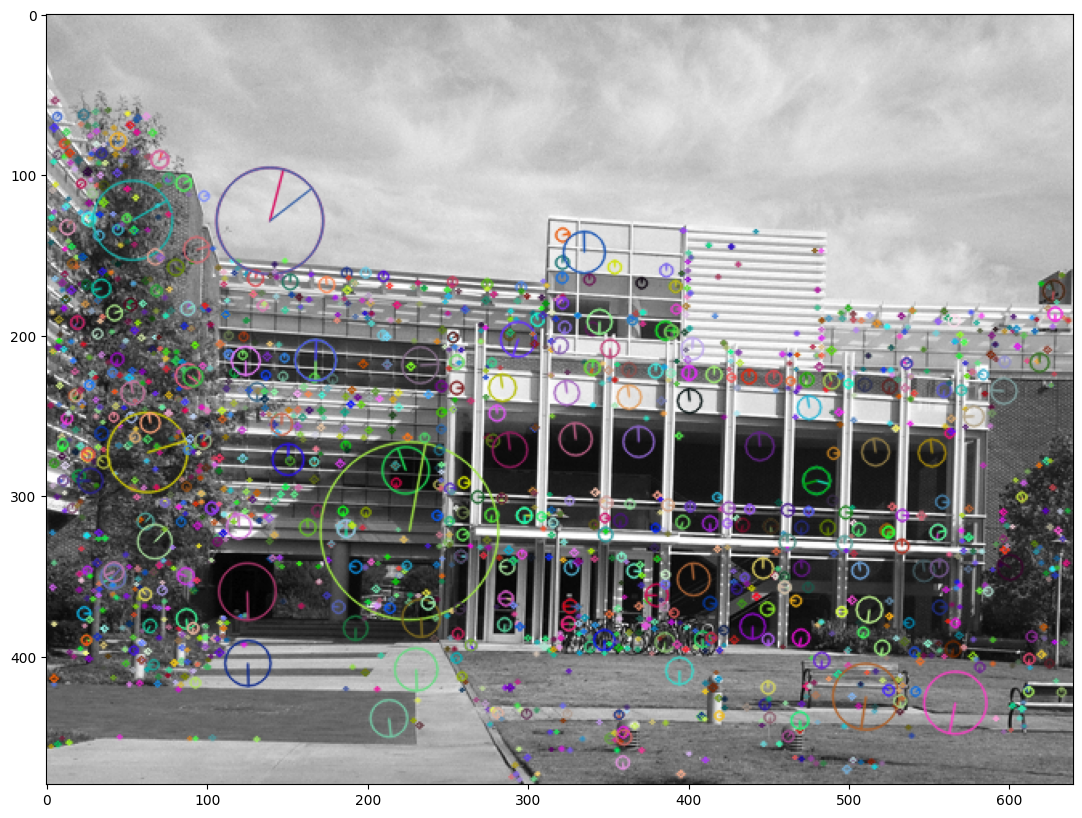

In [ ]:

sift = cv.SIFT_create()
kp, des = sift.detectAndCompute(img_trans_a_uint8, None)
print([(kp.pt, kp.size, kp.angle, kp.response) for kp in kp])

img=cv.drawKeypoints(img_trans_a_uint8, kp, img_trans_a_uint8, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize=(15,10))
plt.imshow(img)
print(des.shape)
print(len(kp))
print(kp[0])    